<h1 align="center">Copules</h1>

Maintenant nous allons nous intéresser à des données multivariées : ici la Seine et la Marne, qui est un de ses affluents. 

L'idée est de pouvoir estimer : 

$$ \lambda_u = \underset{q \to 1}{\lim} \mathbb{P}(X_2 > F_2^{\leftarrow}(q) \vert X_1 > F_1^{\leftarrow}(q)) $$

# Récupération des données

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
import seaborn as sns
import utils

In [2]:
# Seine
seine = pd.read_csv("data/EAUFRANCE-F700000102-Seine_Paris_Austerlitz-limini-1990-2026-Q.csv", sep=",")
seine["date"] = pd.to_datetime(seine["Date (TU)"], format="%Y-%m-%dT%H:%M:%S.000Z")
seine["Q"] = seine["Valeur (en m³/s)"].astype(float)
# Keep only the date and flow rate columns
seine = seine[["date", "Q"]] 
# Sort the data by date
seine = seine.sort_values("date").reset_index(drop=True)
seine.head()

,date,Q
0,1990-02-15,614.0
1,1990-02-16,874.0
2,1990-02-17,842.0
3,1990-02-18,776.0
4,1990-02-19,736.0


In [3]:
seine.describe()

,date,Q
count,3006,3006.000000
mean,2008-08-11 14:47:11.137724672,752.892881
min,1990-02-15 00:00:00,488.000000
25%,2000-01-01 06:00:00,576.000000
50%,2008-04-07 12:00:00,698.000000
75%,2017-03-24 18:00:00,889.750000
max,2026-03-18 00:00:00,1770.000000
std,NaN,218.450134


In [4]:
# Marne
marne = pd.read_csv("data/EAUFRANCE-F664000104-Marne_Noisel-Pont-1996-2026-Q.csv", sep=",")
marne["date"] = pd.to_datetime(marne["Date (TU)"], format="%Y-%m-%dT%H:%M:%S.000Z")
marne["Q"] = marne["Valeur (en m³/s)"].astype(float)
# Keep only the date and flow rate columns
marne = marne[["date", "Q"]] 
# Sort the data by date
marne = marne.sort_values("date").reset_index(drop=True)
marne.head()

,date,Q
0,1996-10-30,32.2
1,1996-10-31,30.1
2,1996-11-01,33.3
3,1996-11-02,38.9
4,1996-11-03,41.5


In [5]:
marne.describe()

,date,Q
count,10740,10740.000000
mean,2011-07-13 12:00:00,116.364572
min,1996-10-30 00:00:00,24.500000
25%,2004-03-06 18:00:00,52.200000
50%,2011-07-13 12:00:00,79.550000
75%,2018-11-18 06:00:00,150.000000
max,2026-03-26 00:00:00,577.000000
std,NaN,92.650242


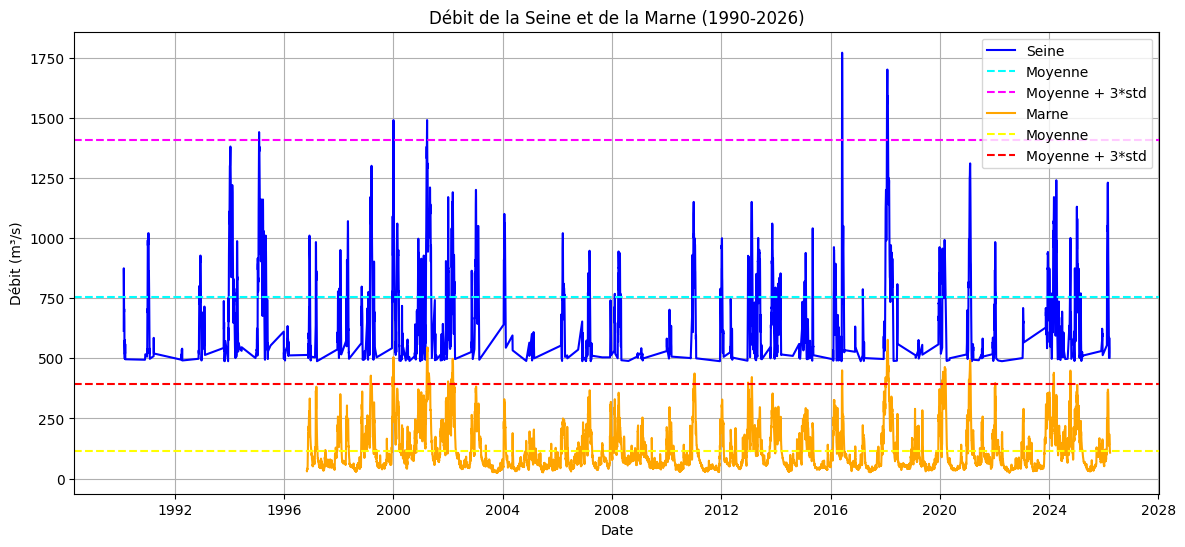

In [6]:
# Plot des deux séries temporelles
plt.figure(figsize=(14, 6))

# SEINE
plt.plot(seine["date"], seine["Q"], label="Seine", color="blue")
# Plot moyenne + moyenne +3*std
plt.axhline(seine["Q"].mean(), label="Moyenne", color="cyan", linestyle="--")
plt.axhline(seine["Q"].mean() + 3*seine["Q"].std(), label="Moyenne + 3*std", color="magenta", linestyle="--")


# MARNE
plt.plot(marne["date"], marne["Q"], label="Marne", color="orange")
plt.axhline(marne["Q"].mean(), label="Moyenne", color="yellow", linestyle="--")
plt.axhline(marne["Q"].mean() + 3*marne["Q"].std(), label="Moyenne + 3*std", color="red", linestyle="--")

plt.title("Débit de la Seine et de la Marne (1990-2026)")
plt.xlabel("Date")
plt.ylabel("Débit (m³/s)")
plt.legend()
plt.grid()

On observe que le débit de la Marne est plus faible que celui de la Seine, ce qui est logique puisque c'est un affluent.

On remarque également que les pics de la Marne sont corrélés avec ceux de la Seine, ce qui suggère une dépendance entre les deux séries temporelles. Là encore, rien d'étonnant puisque la Marne alimente la Seine.

On voit également que les données dépassent régulièrement la barre de trois écarts-types, suggérant une distribution avec des queues plus lourdes que la normale. Vérifions à l'aide de QQ-plots.

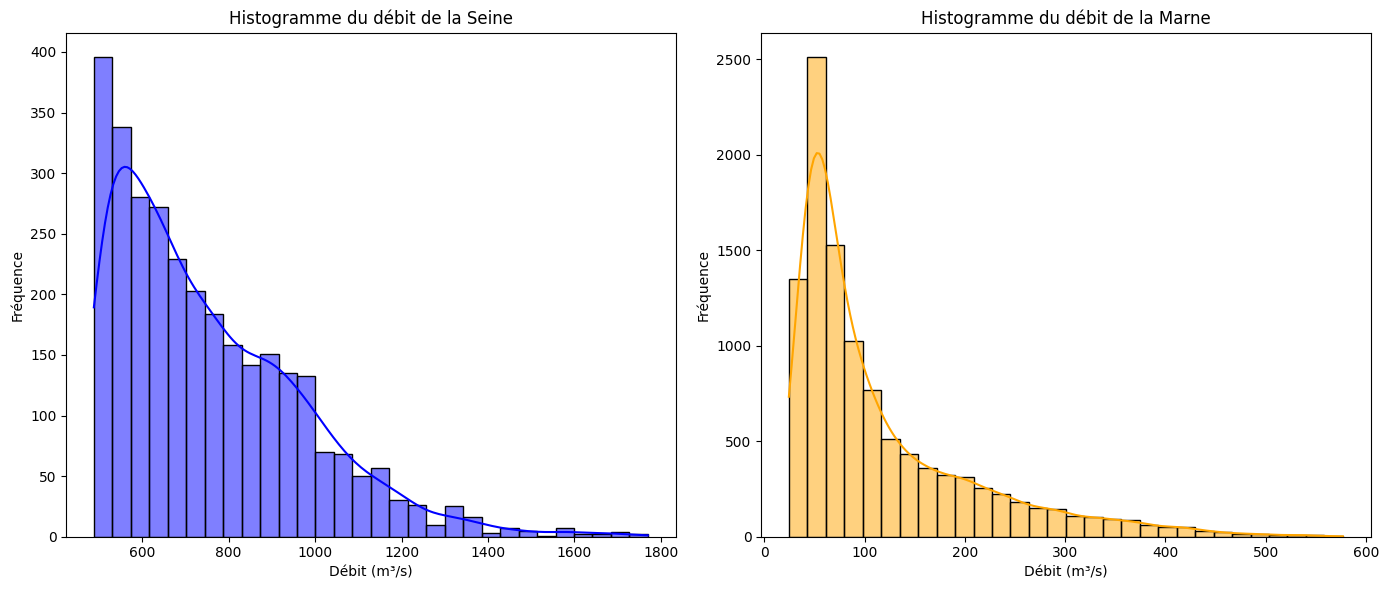

In [7]:
# Histogramme des débits
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.histplot(seine["Q"], bins=30, kde=True, color="blue")
plt.title("Histogramme du débit de la Seine")
plt.xlabel("Débit (m³/s)")
plt.ylabel("Fréquence") 
plt.subplot(1, 2, 2)
sns.histplot(marne["Q"], bins=30, kde=True, color="orange")
plt.title("Histogramme du débit de la Marne")
plt.xlabel("Débit (m³/s)")
plt.ylabel("Fréquence")
plt.tight_layout()
plt.show()

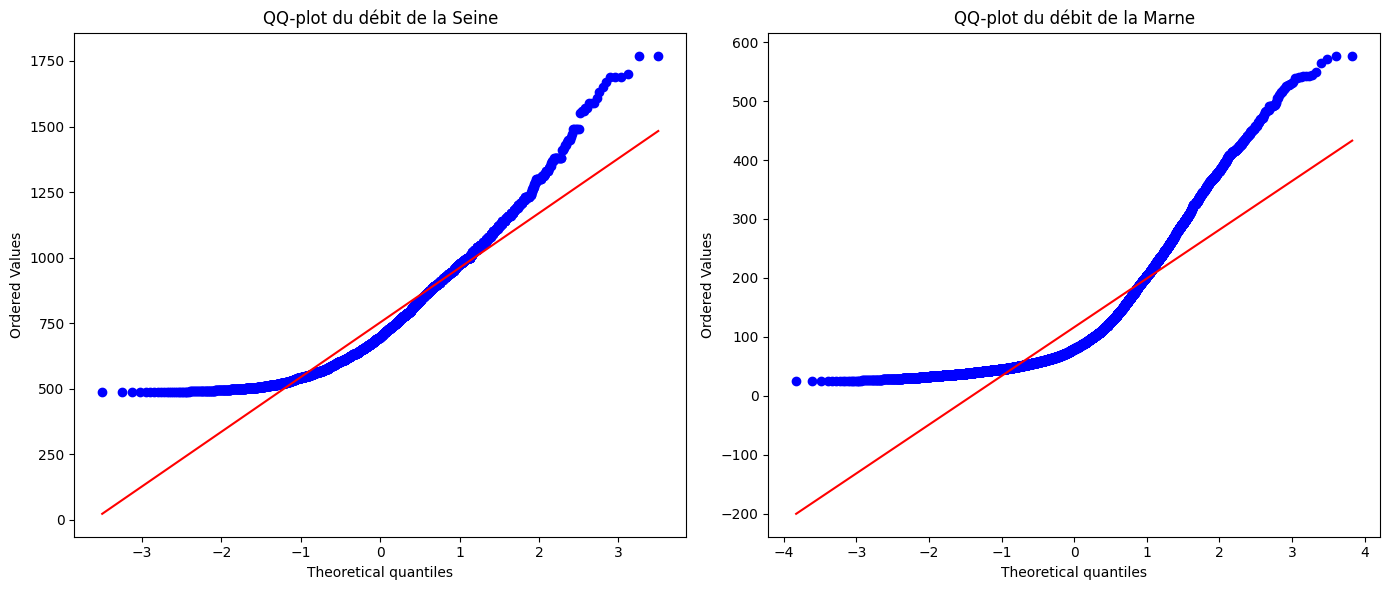

In [8]:
# QQ-plot de la Seine et de la Marne
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
stats.probplot(seine["Q"], dist="norm", plot=plt)
plt.title("QQ-plot du débit de la Seine")
plt.subplot(1, 2, 2)
stats.probplot(marne["Q"], dist="norm", plot=plt)
plt.title("QQ-plot du débit de la Marne")
plt.tight_layout()
plt.show() 

# 1) Nettoyage, mise en correspondance temporelle et pseudo-observations

Objectif : travailler sur des observations $(Q_{\text{Seine}}(t), Q_{\text{Marne}}(t))$ **au même instant** $t$.
On se place ici sur l’intersection des périodes disponibles et on aligne sur la date (données journalières).

Ensuite, on transforme les marges en variables uniformes $(U,V)$ via les **rangs** (pseudo-observations), ce qui permet d’ajuster des copules indépendamment des lois marginales.

In [9]:
# Nettoyage basique
seine_clean = (
    seine.dropna(subset=["date", "Q"])
    .drop_duplicates(subset=["date"])
    .sort_values("date")
    .reset_index(drop=True)
 )
marne_clean = (
    marne.dropna(subset=["date", "Q"])
    .drop_duplicates(subset=["date"])
    .sort_values("date")
    .reset_index(drop=True)
 )

# Mise en correspondance : jointure sur les dates communes
df = pd.merge(
    seine_clean.rename(columns={"Q": "Q_seine"}),
    marne_clean.rename(columns={"Q": "Q_marne"}),
    on="date",
    how="inner",
)
df = df.dropna(subset=["Q_seine", "Q_marne"]).reset_index(drop=True)

print(f"Nombre d'observations couplées : {len(df):,}")
print(f"Période commune : {df['date'].min().date()} → {df['date'].max().date()}")
df.head()

Nombre d'observations couplées : 2,548
Période commune : 1996-11-14 → 2026-03-18


,date,Q_seine,Q_marne
0,1996-11-14,514.0,152.0
1,1996-11-15,559.0,188.0
2,1996-11-16,507.0,170.0
3,1996-11-17,501.0,193.0
4,1996-11-18,507.0,195.0


In [10]:
# Pseudo-observations (rangs) : U,V dans (0,1) - Fonction de répartition empirique
n = len(df)
df["U"] = stats.rankdata(df["Q_seine"], method="average") / (n + 1.0)
df["V"] = stats.rankdata(df["Q_marne"], method="average") / (n + 1.0)

df[["U", "V"]].describe()

,U,V
count,2548.000000,2548.000000
mean,0.500000,0.500000
std,0.288617,0.288616
min,0.001962,0.000392
25%,0.248921,0.251275
50%,0.500196,0.498038
75%,0.749313,0.748921
max,0.999412,0.999412


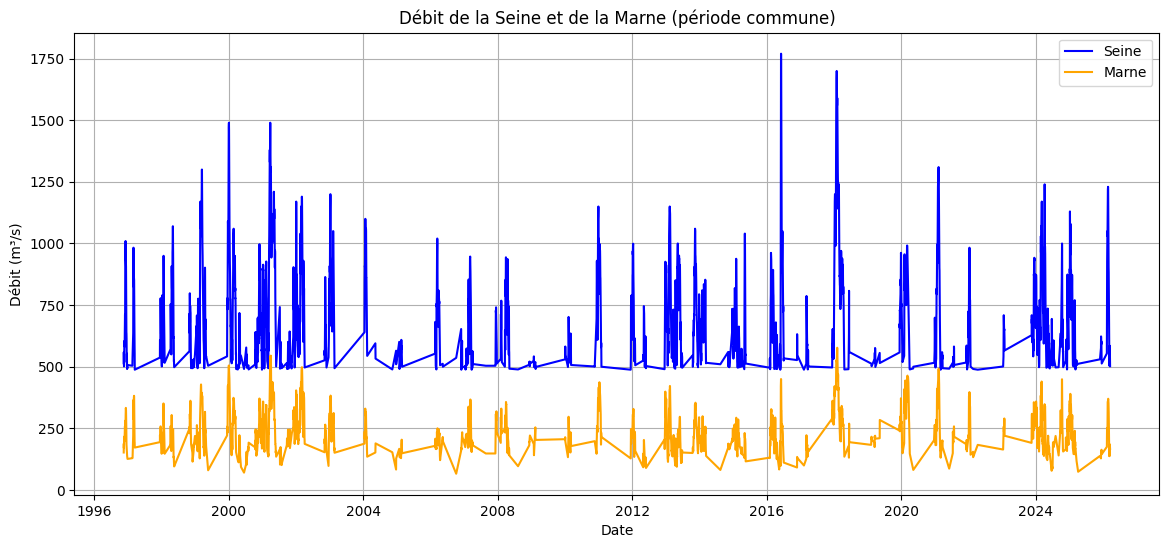

In [11]:
# Affiche les courbes sur la plage commune
plt.figure(figsize=(14, 6))
plt.plot(df["date"], df["Q_seine"], label="Seine", color="blue")
plt.plot(df["date"], df["Q_marne"], label="Marne", color="orange")
plt.title("Débit de la Seine et de la Marne (période commune)")
plt.xlabel("Date")
plt.ylabel("Débit (m³/s)")
plt.legend()
plt.grid()
plt.show()

# 2) Mesures de dépendance : Kendall $\tau$ et Spearman $\rho$

On calcule ces mesures **sur les débits** et sur les **pseudo-observations** (elles coïncident pour Kendall/Spearman car basées sur les rangs).

In [12]:
tau, tau_p = stats.kendalltau(df["Q_seine"], df["Q_marne"])
rho, rho_p = stats.spearmanr(df["Q_seine"], df["Q_marne"])

print(f"Kendall tau   = {tau:.4f}  (p-value={tau_p:.2e})")
print(f"Spearman rho  = {rho:.4f}  (p-value={rho_p:.2e})")

Kendall tau   = 0.6270  (p-value=0.00e+00)
Spearman rho  = 0.8204  (p-value=0.00e+00)


- **Que mesurent $\tau$ et $\rho$ ?** Ce sont des mesures **non paramétriques** de dépendance (basées sur les rangs). Elles sont robustes aux changements d’échelle et cohérentes avec la logique copule : elles décrivent la dépendance **marginale-invariante**.

- **Interprétation du signe et de l’intensité** :
  - Valeurs **positives** $\Rightarrow$ les grands débits de la Seine tendent à coïncider avec de grands débits de la Marne (association croissante).
  - Plus $|\tau|$ et $|\rho|$ sont grands, plus la dépendance monotone est forte.

- **Interprétation des p-values** : la p-value teste l’hypothèse d’**indépendance** (pas d’association). Une p-value très petite signifie qu’on rejette l’indépendance **au sens statistique** (association détectable), **mais ne quantifie pas** l’importance hydrologique du phénomène.

- **Attention (séries temporelles)** : les observations journalières sont souvent **autocorrélées** (crues multi-jours). Cela peut rendre les p-values *trop optimistes* (taille d’échantillon « effective » plus petite). Pour une inférence plus rigoureuse, on peut :
  - faire du **declustering** (ne garder que les pics indépendants), ou
  - utiliser un **bootstrap en blocs**.

Ces mesures donnent une première lecture « globale » de la dépendance ; la suite (copules + $\lambda_U$) vise ensuite à qualifier plus finement la **dépendance en queue** (co-occurrence des extrêmes).

# 3) Ajustement de copules (Gaussienne, Clayton, Gumbel)

On ajuste des copules sur les pseudo-observations $(U,V)$.
- La **gaussienne** capture une dépendance « symétrique » sans dépendance de queue.
- **Clayton** a une dépendance de **queue inférieure** (gauche).
- **Gumbel** a une dépendance de **queue supérieure** (droite), pertinente pour des crues conjointes.

On utilise ici la bibliothèque `copulas` (copules bivariées).

In [13]:
# Ajustement à l'API `copulas==0.14.x` (SDV)
import copulas
from copulas.bivariate import Bivariate, CopulaTypes
from copulas.multivariate import GaussianMultivariate

print("copulas version:", getattr(copulas, "__version__", "(unknown)"))

uv = df[["U", "V"]].to_numpy()

# 1) Gaussienne (approche multivariée en dimension 2)
cop_gauss = GaussianMultivariate()
cop_gauss.fit(df[["U", "V"]])

# 2) Archimédiennes (bivariées)
cop_clayton = Bivariate(copula_type=CopulaTypes.CLAYTON)
cop_gumbel = Bivariate(copula_type=CopulaTypes.GUMBEL)

cop_clayton.fit(uv)
cop_gumbel.fit(uv)

print("Gaussian correlation matrix:\n", cop_gauss.correlation)
print("Clayton theta:", cop_clayton.theta)
print("Gumbel  theta:", cop_gumbel.theta)

fitted = {"gaussian": cop_gauss, "clayton": cop_clayton, "gumbel": cop_gumbel}

copulas version: 0.14.1
Gaussian correlation matrix:
          U        V
U  1.00000  0.78639
V  0.78639  1.00000
Clayton theta: 3.3621539219436025
Gumbel  theta: 2.6810769609718013


In [14]:
# Dépendance de queue supérieure : λ_U

# Coefficient théorique (dépendance asymptotique de queue supérieure)
# - Gaussienne : λ_U = 0 (sauf corrélation parfaite)
# - Clayton    : dépendance de queue inférieure, donc λ_U = 0
# - Gumbel     : λ_U = 2 - 2^(1/θ)

lambda_u_gauss = 0.0
lambda_u_clayton = 0.0
lambda_u_gumbel = 2 - 2 ** (1 / cop_gumbel.theta)

print("λ_U (théorique) :")
print(f"- Gaussienne : {lambda_u_gauss:.3f}")
print(f"- Clayton    : {lambda_u_clayton:.3f}")
print(f"- Gumbel     : {lambda_u_gumbel:.3f}")

λ_U (théorique) :
- Gaussienne : 0.000
- Clayton    : 0.000
- Gumbel     : 0.705



λ_U empirique (quelques points) :
  q=0.900 → λ_U(q)≈0.656
  q=0.920 → λ_U(q)≈0.626
  q=0.940 → λ_U(q)≈0.547
  q=0.960 → λ_U(q)≈0.606
  q=0.980 → λ_U(q)≈0.750


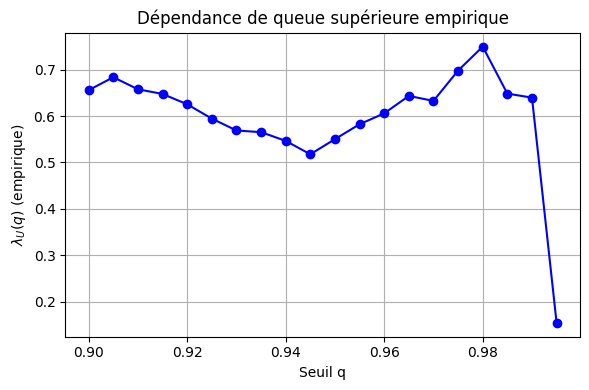

In [15]:

# Estimateur empirique (sur pseudo-observations)
u = df["U"].to_numpy()
v = df["V"].to_numpy()

def empirical_lambda_u(u, v, q):
    num = np.sum((u > q) & (v > q))
    den = np.sum(u > q)
    return num / den if den > 0 else np.nan

# Grille plus dense en q (plus de points pour une courbe plus lisse)
q_grid = np.linspace(0.90, 0.995, 20)
emp_lu = [empirical_lambda_u(u, v, q) for q in q_grid]

print("\nλ_U empirique (quelques points) :")
for q, val in zip(q_grid[::4], emp_lu[::4]):
    print(f"  q={q:.3f} → λ_U(q)≈{val:.3f}")

# Courbe
plt.figure(figsize=(6, 4))
plt.plot(q_grid, emp_lu, marker="o", linestyle="-", color="blue")
plt.xlabel("Seuil q")
plt.ylabel(r"$\lambda_U(q)$ (empirique)")
plt.title("Dépendance de queue supérieure empirique")
plt.grid(True)
plt.tight_layout()
plt.show()

# 4) Graphiques utiles

On visualise :
- nuage $(Q_{\text{Seine}}, Q_{\text{Marne}})$ et nuage $(U,V)$ ;
- densité/contours de la copule ajustée ;
- estimation empirique de $\lambda_U(q)$ en fonction de $q$.

Remarque : la copule s’ajuste sur $(U,V)$, donc les diagnostics les plus “propres” se font dans le plan uniforme.

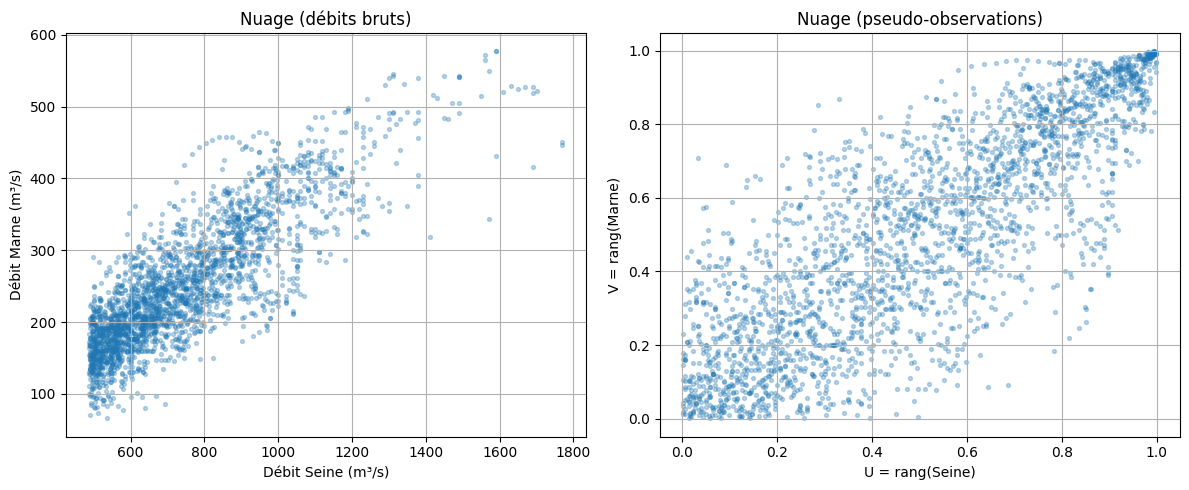

In [16]:
# Nuages de points
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].scatter(df["Q_seine"], df["Q_marne"], s=8, alpha=0.3)
ax[0].set_xlabel("Débit Seine (m³/s)")
ax[0].set_ylabel("Débit Marne (m³/s)")
ax[0].set_title("Nuage (débits bruts)")
ax[0].grid(True)

ax[1].scatter(df["U"], df["V"], s=8, alpha=0.3)
ax[1].set_xlabel("U = rang(Seine)")
ax[1].set_ylabel("V = rang(Marne)")
ax[1].set_title("Nuage (pseudo-observations)")
ax[1].grid(True)

plt.tight_layout()
plt.show()

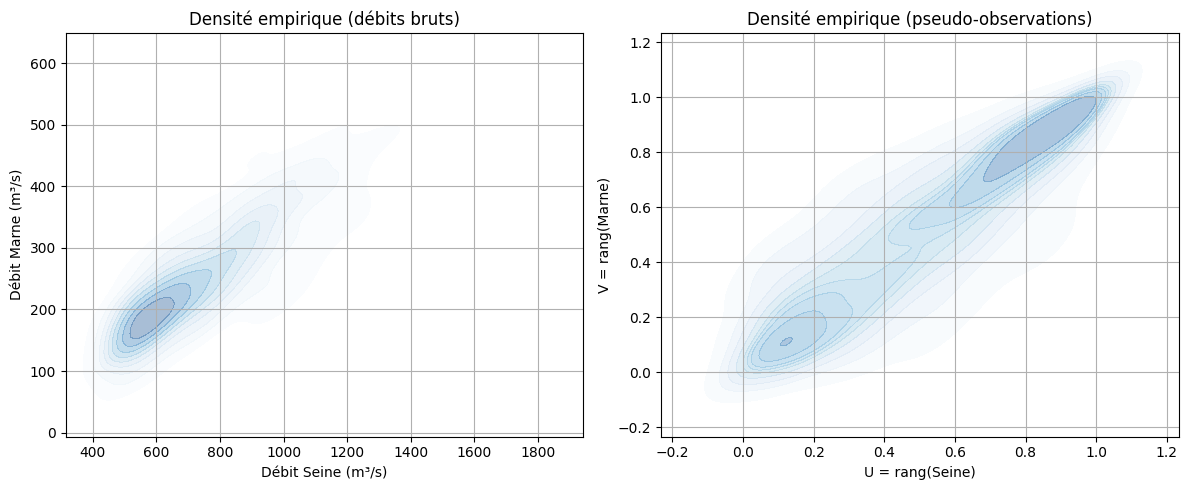

In [17]:
# Contours de densité empirique dans (U,V)
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# (a) Débits bruts
# ax[0].scatter(df["Q_seine"], df["Q_marne"], s=8, alpha=0.25, c="black")
sns.kdeplot(
    x=df["Q_seine"],
    y=df["Q_marne"],
    fill=True,
    levels=10,
    thresh=0.05,
    alpha=0.35,
    cmap="Blues", 
    ax=ax[0],
)
ax[0].set_xlabel("Débit Seine (m³/s)")
ax[0].set_ylabel("Débit Marne (m³/s)")
ax[0].set_title("Densité empirique (débits bruts)")
ax[0].grid(True)

# (b) Pseudo-observations (U,V)
# ax[1].scatter(df["U"], df["V"], s=8, alpha=0.25, c="black")
sns.kdeplot(
    x=df["U"],
    y=df["V"],
    fill=True,
    levels=10,
    thresh=0.05,
    alpha=0.35,
    cmap="Blues",
    ax=ax[1],
)
ax[1].set_xlabel("U = rang(Seine)")
ax[1].set_ylabel("V = rang(Marne)")
ax[1].set_title("Densité empirique (pseudo-observations)")
ax[1].grid(True)

plt.tight_layout()
plt.show()

Cette densité plus importante sur les extrêmes suggère une dépendance dans les extrêmes, ce qui paraît cohérent avec la nature hydrologique des données (crues conjointes ou sécheresses). Cela justifie l’utilisation de copules avec dépendance de queue (ex : Gumbel) pour modéliser ce phénomène.

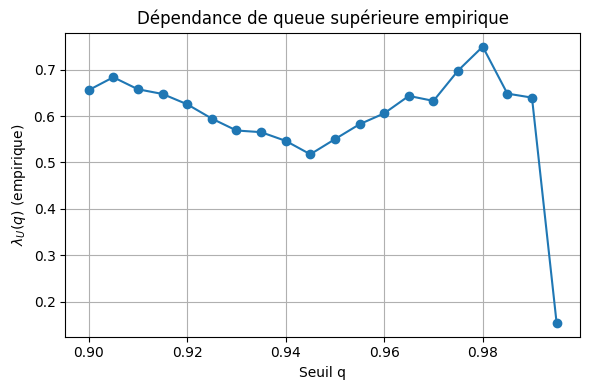

In [18]:
# Comparaison : λ_U(q) empirique
plt.figure(figsize=(6, 4))
plt.plot(q_grid, emp_lu, marker="o")
plt.xlabel("Seuil q")
plt.ylabel(r"$\lambda_U(q)$ (empirique)")
plt.title("Dépendance de queue supérieure empirique")
plt.grid(True)
plt.tight_layout()
plt.show()

# 5) Variante avec *declustering* (pics indépendants)

Objectif : réduire l'impact de la **dépendance temporelle** (une crue dure plusieurs jours) en ne gardant que des **pics indépendants** espacés d'au moins `run_length` jours.

- On **ne modifie pas** `df` ; on crée un nouveau DataFrame `df_declust`.
- On refait ensuite (i) le calcul de \(\tau\), \(\rho\), (ii) l'ajustement des copules et (iii) l'estimation de \(\lambda_U\) sur l'échantillon declustérisé.


In [19]:
# --- Declustering: extraction de pics indépendants (simple et explicite) ---
# Paramètre : nombre minimal de jours séparant deux pics conservés
run_length = 7  # à ajuster (ex: 5, 7, 10)

# Score d'événement : max des rangs (U,V)
score = df[["U", "V"]].max(axis=1)

# Tri décroissant des candidats, puis sélection avec contrainte de séparation temporelle
candidates = df.assign(_score=score).sort_values("_score", ascending=False)

selected_idx = []
selected_dates = []
for idx, row in candidates.iterrows():
    d = pd.to_datetime(row["date"])
    if all(abs((d - d2).days) >= run_length for d2 in selected_dates):
        selected_idx.append(idx)
        selected_dates.append(d)

# Sous-échantillon declustérisé, remis dans l'ordre temporel
# (on garde aussi U,V déjà calculés pour pouvoir refaire les étapes ensuite)
df_declust = df.loc[selected_idx].sort_values("date").reset_index(drop=True)

print(f"Declustering avec run_length={run_length} jours")
print(f"- Taille originale : {len(df)}")
print(f"- Taille declustérisée : {len(df_declust)}")
print(f"- Période : {df_declust['date'].min().date()} → {df_declust['date'].max().date()}")
df_declust.describe()

Declustering avec run_length=7 jours
- Taille originale : 2548
- Taille declustérisée : 371
- Période : 1996-11-20 → 2026-03-15


,date,Q_seine,Q_marne,U,V
count,371,371.000000,371.000000,371.000000,371.000000
mean,2011-03-09 10:28:47.223719680,754.851752,252.757143,0.502602,0.505464
min,1996-11-20 00:00:00,488.000000,65.900000,0.001962,0.000392
25%,2001-12-05 12:00:00,567.500000,187.000000,0.228913,0.251275
50%,2012-05-23 00:00:00,718.000000,236.000000,0.533935,0.511965
75%,2018-04-16 12:00:00,902.500000,309.000000,0.784425,0.763044
max,2026-03-15 00:00:00,1770.000000,577.000000,0.999412,0.999412
std,NaN,225.835463,95.518473,0.305025,0.302224


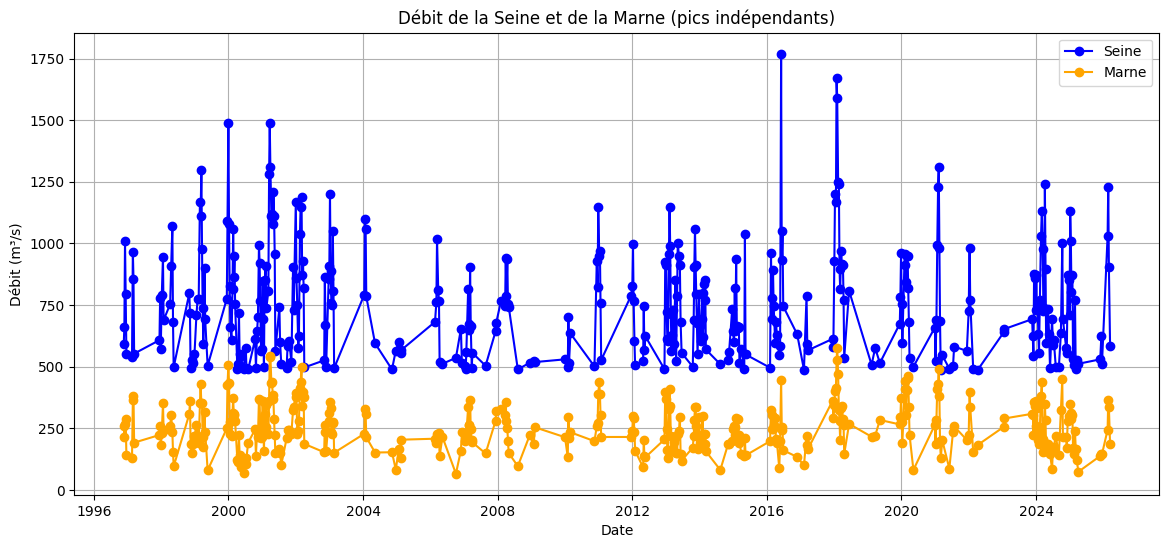

In [20]:
# Plot the flow rate over time
plt.figure(figsize=(14, 6))
plt.plot(df_declust["date"], df_declust["Q_seine"], label="Seine", color="blue", marker="o", linestyle="-")
plt.plot(df_declust["date"], df_declust["Q_marne"], label="Marne", color="orange", marker="o", linestyle="-")
plt.title("Débit de la Seine et de la Marne (pics indépendants)")
plt.xlabel("Date")
plt.ylabel("Débit (m³/s)")
plt.legend()
plt.grid()
plt.show()

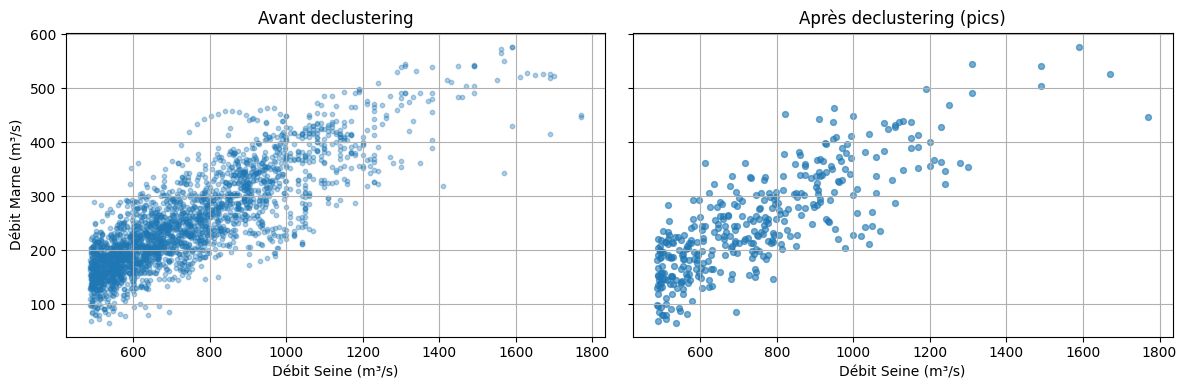

In [21]:
# Mise en évidence avant/après
fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True)
ax[0].scatter(df["Q_seine"], df["Q_marne"], s=10, alpha=0.35)
ax[0].set_title("Avant declustering")
ax[0].set_xlabel("Débit Seine (m³/s)")
ax[0].set_ylabel("Débit Marne (m³/s)")
ax[0].grid(True)

ax[1].scatter(df_declust["Q_seine"], df_declust["Q_marne"], s=18, alpha=0.6)
ax[1].set_title("Après declustering (pics)")
ax[1].set_xlabel("Débit Seine (m³/s)")
ax[1].grid(True)

plt.tight_layout()
plt.show()

In [22]:
# --- Dépendance globale (declustering) ---
tau_d, tau_p_d = stats.kendalltau(df_declust["Q_seine"], df_declust["Q_marne"])
rho_d, rho_p_d = stats.spearmanr(df_declust["Q_seine"], df_declust["Q_marne"])

print("[Declustering]")
print(f"Kendall tau   = {tau_d:.4f}  (p-value={tau_p_d:.2e})")
print(f"Spearman rho  = {rho_d:.4f}  (p-value={rho_p_d:.2e})")

# Recalcul des pseudo-observations sur l'échantillon declustérisé (n différent)
u_d = df_declust["Q_seine"].rank(method="average") / (len(df_declust) + 1)
v_d = df_declust["Q_marne"].rank(method="average") / (len(df_declust) + 1)

df_declust = df_declust.assign(U=u_d, V=v_d)
display(df_declust[["U", "V"]].describe())

[Declustering]
Kendall tau   = 0.6021  (p-value=7.81e-67)
Spearman rho  = 0.8007  (p-value=4.05e-84)


,U,V
count,371.000000,371.000000
mean,0.500000,0.500000
std,0.288284,0.288282
min,0.005376,0.002688
25%,0.252016,0.251344
50%,0.498656,0.497312
75%,0.748656,0.748656
max,0.997312,0.997312


In [23]:
# --- Ajustement des copules (declustering) ---
uv_d = df_declust[["U", "V"]].to_numpy()

cop_gauss_d = GaussianMultivariate()
cop_gauss_d.fit(df_declust[["U", "V"]])

cop_clayton_d = Bivariate(copula_type=CopulaTypes.CLAYTON)
cop_gumbel_d = Bivariate(copula_type=CopulaTypes.GUMBEL)

cop_clayton_d.fit(uv_d)
cop_gumbel_d.fit(uv_d)

print("[Declustering] paramètres ajustés")
print("Gaussian correlation matrix:\n", cop_gauss_d.correlation)
print("Clayton theta:", cop_clayton_d.theta)
print("Gumbel  theta:", cop_gumbel_d.theta)

fitted_d = {"gaussian": cop_gauss_d, "clayton": cop_clayton_d, "gumbel": cop_gumbel_d}

[Declustering] paramètres ajustés
Gaussian correlation matrix:
           U         V
U  1.000000  0.734239
V  0.734239  1.000000
Clayton theta: 3.026043615256926
Gumbel  theta: 2.513021807628463


[Declustering] λ_U (théorique) :
- Gaussienne : 0.000
- Clayton    : 0.000
- Gumbel     : 0.682

[Declustering] λ_U empirique (quelques points) :
  q=0.900 → λ_U(q)≈0.605
  q=0.919 → λ_U(q)≈0.600
  q=0.939 → λ_U(q)≈0.476
  q=0.958 → λ_U(q)≈0.533
  q=0.977 → λ_U(q)≈0.750


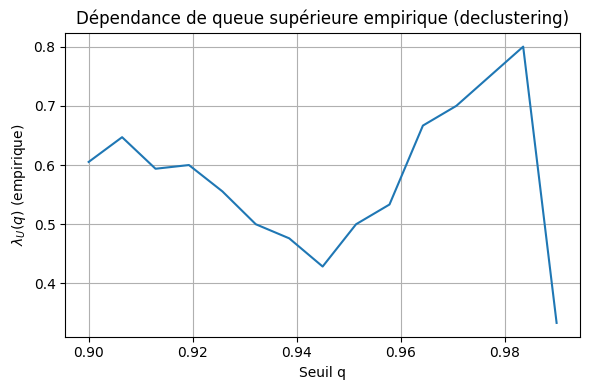

In [24]:
# --- Dépendance de queue supérieure (declustering) ---
# Théorie
lambda_u_gauss_d = 0.0
lambda_u_clayton_d = 0.0
lambda_u_gumbel_d = 2 - 2 ** (1 / cop_gumbel_d.theta)

print("[Declustering] λ_U (théorique) :")
print(f"- Gaussienne : {lambda_u_gauss_d:.3f}")
print(f"- Clayton    : {lambda_u_clayton_d:.3f}")
print(f"- Gumbel     : {lambda_u_gumbel_d:.3f}")

# Empirique
U_d = df_declust["U"].to_numpy()
V_d = df_declust["V"].to_numpy()

# Grille plus dense (attention : sur df_declust plus petit, les q très proches de 1 deviennent instables)
q_grid_d = np.linspace(0.90, 0.99, 15)
emp_lu_d = []

for q0 in q_grid_d:
    num = np.sum((U_d > q0) & (V_d > q0))
    den = np.sum(U_d > q0)
    emp_lu_d.append(num / den if den > 0 else np.nan)

print("\n[Declustering] λ_U empirique (quelques points) :")
for q0, val0 in zip(q_grid_d[::3], np.array(emp_lu_d)[::3]):
    print(f"  q={q0:.3f} → λ_U(q)≈{val0:.3f}")

plt.figure(figsize=(6, 4))
plt.plot(q_grid_d, emp_lu_d)
plt.xlabel("Seuil q")
plt.ylabel(r"$\lambda_U(q)$ (empirique)")
plt.title("Dépendance de queue supérieure empirique (declustering)")
plt.grid(True)
plt.tight_layout()
plt.show()

Finalement cela ne change pas grand-chose.

# 6) Analyse des résultats et conclusion

## 6.1 Résultats numériques (période commune)
- Nombre d'observations couplées : **2548** (1996-11-14 → 2026-03-18)
- Dépendance globale : Kendall $\tau \approx 0.627$ ; Spearman $\rho \approx 0.820$ (p-values ~ 0)
- Ajustements (package `copulas`) :
  - Gaussienne (corrélation sur $(U,V)$) : $\rho \approx 0.786$
  - Clayton : $\theta \approx 3.36$ (dépendance de queue **inférieure**, pas de queue supérieure)
  - Gumbel : $\theta \approx 2.68$ (dépendance de queue **supérieure**)

## 6.2 Dépendance de queue supérieure
- Théorie :
  - Gaussienne : $\lambda_U = 0$
  - Clayton : $\lambda_U = 0$
  - Gumbel : $\lambda_U = 2 - 2^{1/\theta} \approx 0.705$
- Empirique : $\lambda_U(q)$ est autour de **0.55–0.75** pour $q \in [0.95,0.99]$ (avec forte variabilité due au faible nombre de points extrêmes).

## Conclusion (à remettre)
Les deux séries présentent une dépendance positive forte (\(\tau\) et \(\rho\) élevés). L'analyse de queue supérieure suggère une **co-occurrence non négligeable des fortes crues** : l'estimateur empirique $\lambda_U(q)$ reste nettement positif aux seuils élevés, ce qui est cohérent avec une copule **de type Gumbel** (dépendance de queue supérieure), plutôt qu'une copule gaussienne (pas de dépendance asymptotique de queue) ou Clayton (plutôt orientée queue inférieure).

## Limites / pistes d'amélioration
- **Dépendance temporelle** (jours consécutifs en crue) : faire du *declustering* avant d'estimer $\lambda_U$.
- **Saisonnalité** : refaire l'analyse sur une saison hydrologique (ex. hiver) et comparer.
- **Stationnarité** : tester la robustesse par sous-périodes (avant/après aménagements, etc.).
- Ajouter une copule **Student** (dépendance de queue symétrique) et comparer via un critère (pseudo-log-vraisemblance / AIC).